# Comparação de Modelos: Recursivo vs Seq2Seq para Previsão de Carga Energética

In [1]:
import gc
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import time
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import LSTM, Dense, RepeatVector, TimeDistributed
from sklearn.metrics import mean_absolute_error, mean_squared_error

2025-09-22 22:24:54.265132: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-09-22 22:24:54.265345: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-22 22:24:54.297612: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-09-22 22:24:55.251190: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off,

In [2]:
# Carregar dados
df = pd.read_csv("../data/carga_ons.csv", index_col=0, parse_dates=True)
col = "SUDESTE"

data = df[[col]]

# Normalizar dados
scaler = MinMaxScaler()
scaled = scaler.fit_transform(data)

## Modelo Recursivo (24h entrada → 1h saída, repetido 24x)

In [3]:
# Preparar dados
X_rec, y_rec = [], []
for i in range(len(scaled) - 24):
    X_rec.append(scaled[i:i+24])
    y_rec.append(scaled[i+24])
X_rec, y_rec = np.array(X_rec), np.array(y_rec)
X_rec = X_rec.reshape((X_rec.shape[0], 24, 1))

# Treinar modelo
model_rec = Sequential([
    LSTM(64, input_shape=(24,1)),
    Dense(1)
])
model_rec.compile(optimizer='adam', loss='mse')
start_train_rec = time.time()
model_rec.fit(X_rec, y_rec, epochs=50, batch_size=32, verbose=1)  # type: ignore
end_train_rec = time.time()
print(f"Tempo de treino: {end_train_rec - start_train_rec:.2f} segundos")

# Previsão recursiva
last_sequence = scaled[-24:].reshape(1, 24, 1)
preds = []
start_pred_rec = time.time()
for _ in range(24):
    pred = model_rec.predict(last_sequence, verbose=1)[0,0]  # type: ignore
    preds.append(pred)
    last_sequence = np.append(last_sequence[:,1:,:], [[[pred]]], axis=1)
end_pred_rec = time.time()
print(f"Tempo de previsão: {end_pred_rec - start_pred_rec:.4f} segundos")
preds_inv = scaler.inverse_transform(np.array(preds).reshape(-1,1)).flatten()
print(preds_inv)

# Liberar memória
del model_rec
gc.collect()

2025-09-22 22:24:58.000715: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/home/jean/Documents/TCC/venv/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
6984/6984 ━━━━━━━━━━━━━━━━━━━━ 29s 4ms/step - loss: 9.9866e-04
Epoch 2/50
6984/6984 ━━━━━━━━━━━━━━━━━━━━ 30s 4ms/step - loss: 2.6973e-04
Epoch 3/50
6984/6984 ━━━━━━━━━━━━━━━━━━━━ 31s 4ms/step - loss: 1.5884e-04
Epoch 4/50
6984/6984 ━━━━━━━━━━━━━━━━━━━━ 31s 4ms/step - loss: 1.3296e-04
Epoch 5/50
6984/6984 ━━━━━━━━━━━━━━━━━━━━ 31s 4ms/step - loss: 1.1976e-04
Epoch 6/50
6984/6984 ━━━━━━━━━━━━━━━━━━━━ 31s 4ms/step - loss: 1.0752e-04
Epoch 7/50
6984/6984 ━━━━━━━━━━━━━━━━━━━━ 32s 5ms/step - loss: 9.8546e-05
Epoch 8/50
6984/6984 ━━━━━━━━━━━━━━━━━━━━ 31s 4ms/step - loss: 9.0626e-05
Epoch 9/50
6984/6984 ━━━━━━━━━━━━━━━━━━━━ 31s 4ms/step - loss: 8.4906e-05
Epoch 10/50
6984/6984 ━━━━━━━━━━━━━━━━━━━━ 32s 5ms/step - loss: 7.9480e-05
Epoch 11/50
6984/6984 ━━━━━━━━━━━━━━━━━━━━ 31s 4ms/step - loss: 7.5571e-05
Epoch 12/50
6984/6984 ━━━━━━━━━━━━━━━━━━━━ 31s 5ms/step - loss: 7.2129e-05
Epoch 13/50
6984/6984 ━━━━━━━━━━━━━━━━━━━━ 32s 5ms/step - loss: 6.8626e-05
Epoch 14/50
6984/6984 ━━━━━━━━━━━━

6567

## 📦 Modelo Seq2Seq (24h entrada → 24h saída)

In [4]:
# Preparar dados seq2seq
X_seq, y_seq = [], []
for i in range(len(scaled) - 48):
    X_seq.append(scaled[i:i+24])
    y_seq.append(scaled[i+24:i+48])
X_seq = np.array(X_seq)
y_seq = np.array(y_seq)
X_seq = X_seq.reshape((X_seq.shape[0], 24, 1))
y_seq = y_seq.reshape((y_seq.shape[0], 24, 1))

# Treinar modelo Seq2Seq
model_seq = Sequential([
    LSTM(64, input_shape=(24,1)),
    RepeatVector(24),
    LSTM(64, return_sequences=True),
    TimeDistributed(Dense(1))
])
model_seq.compile(optimizer='adam', loss='mse')
start_train = time.time()
model_seq.fit(X_seq, y_seq, epochs=50, batch_size=32, verbose=1)  # type: ignore
end_train = time.time()
print(f"Tempo de treino: {end_train - start_train:.2f} segundos")

# Previsão seq2seq
input_seq = scaled[-48:-24].reshape(1, 24, 1)
start_pred_seq = time.time()
pred_seq = model_seq.predict(input_seq, verbose=1).reshape(24)  # type: ignore
end_pred_seq = time.time()
print(f"Tempo de previsão: {end_pred_seq - start_pred_seq:.4f} segundos")
pred_seq_inv = scaler.inverse_transform(pred_seq.reshape(-1, 1)).flatten()
print(pred_seq_inv)

# Liberar memória
del model_seq
gc.collect()

Epoch 1/50


/home/jean/Documents/TCC/venv/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  18/6983 ━━━━━━━━━━━━━━━━━━━━ 1:05 9ms/step - loss: 0.1090 

2025-09-22 22:45:27.364440: E tensorflow/core/util/util.cc:131] oneDNN supports DT_INT32 only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


6983/6983 ━━━━━━━━━━━━━━━━━━━━ 57s 8ms/step - loss: 0.0041
Epoch 2/50
6983/6983 ━━━━━━━━━━━━━━━━━━━━ 56s 8ms/step - loss: 0.0016
Epoch 3/50
6983/6983 ━━━━━━━━━━━━━━━━━━━━ 55s 8ms/step - loss: 0.0013
Epoch 4/50
6983/6983 ━━━━━━━━━━━━━━━━━━━━ 55s 8ms/step - loss: 0.0011
Epoch 5/50
6983/6983 ━━━━━━━━━━━━━━━━━━━━ 56s 8ms/step - loss: 9.7151e-04
Epoch 6/50
6983/6983 ━━━━━━━━━━━━━━━━━━━━ 56s 8ms/step - loss: 8.8511e-04
Epoch 7/50
6983/6983 ━━━━━━━━━━━━━━━━━━━━ 56s 8ms/step - loss: 8.0501e-04
Epoch 8/50
6983/6983 ━━━━━━━━━━━━━━━━━━━━ 56s 8ms/step - loss: 7.4093e-04
Epoch 9/50
6983/6983 ━━━━━━━━━━━━━━━━━━━━ 56s 8ms/step - loss: 7.0005e-04
Epoch 10/50
6983/6983 ━━━━━━━━━━━━━━━━━━━━ 56s 8ms/step - loss: 6.7308e-04
Epoch 11/50
6983/6983 ━━━━━━━━━━━━━━━━━━━━ 56s 8ms/step - loss: 6.4965e-04
Epoch 12/50
6983/6983 ━━━━━━━━━━━━━━━━━━━━ 56s 8ms/step - loss: 6.2683e-04
Epoch 13/50
6983/6983 ━━━━━━━━━━━━━━━━━━━━ 56s 8ms/step - loss: 6.0909e-04
Epoch 14/50
6983/6983 ━━━━━━━━━━━━━━━━━━━━ 56s 8ms/step - los

6497

## Comparação das Métricas

In [5]:
# Valores reais
y_true = data[col].iloc[-24:].values

# Função de avaliação
def calcular_metricas(y_true, y_pred, nome_modelo):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((y_true - y_pred) / np.where(y_true == 0, 1e-10, y_true))) * 100
    print(f"\nMétricas para o modelo: {nome_modelo}")
    print(f"MAE :  {mae:.2f}")
    print(f"MSE :  {mse:.2f}")
    print(f"RMSE:  {rmse:.2f}")
    print(f"MAPE:  {mape:.2f}%")

# Avaliação
calcular_metricas(y_true, preds_inv, "Recursivo")
calcular_metricas(y_true, pred_seq_inv, "Seq2Seq")



Métricas para o modelo: Recursivo
MAE :  3082.43
MSE :  13611880.60
RMSE:  3689.43
MAPE:  8.65%

Métricas para o modelo: Seq2Seq
MAE :  1079.29
MSE :  1720080.09
RMSE:  1311.52
MAPE:  3.13%


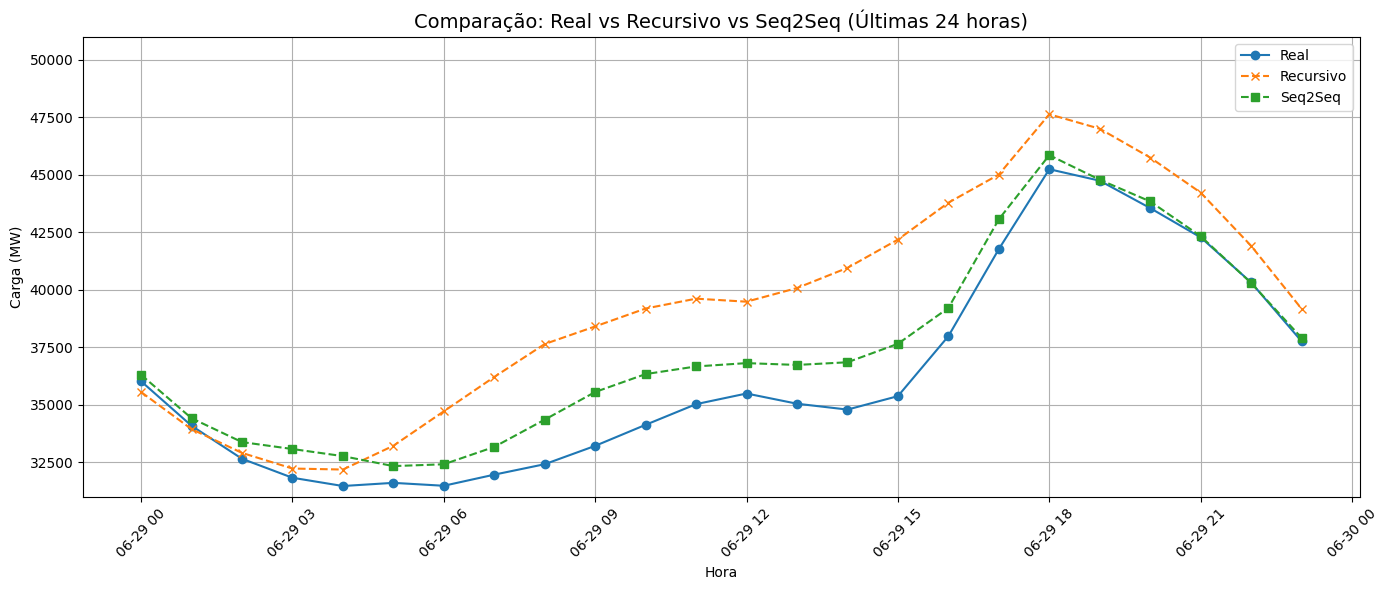

In [6]:
# Criar eixo de tempo (últimos 24 timestamps)
eixo_tempo = data.index[-24:]

# Plotar
plt.figure(figsize=(14, 6))
plt.plot(eixo_tempo, np.asarray(y_true), label='Real', marker='o')
plt.plot(eixo_tempo, np.asarray(preds_inv), label='Recursivo', linestyle='--', marker='x')
plt.plot(eixo_tempo, np.asarray(pred_seq_inv), label='Seq2Seq', linestyle='--', marker='s')

plt.ylim(31000, 51000)

plt.title("Comparação: Real vs Recursivo vs Seq2Seq (Últimas 24 horas)", fontsize=14)
plt.xlabel("Hora")
plt.ylabel("Carga (MW)")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()